### Autoreload

Autoreload allows the notebook to dynamically load code: if we update some helper functions *outside* of the notebook, we do not need to reload the notebook.

In [215]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [216]:
# All auxiliary code is in ../src

import sys

sys.path.append("../src/")

# Data understanding

As first thing we imported all the necessary modules.

In [217]:
import pandas as pd
import seaborn as sbn
import matplotlib.pyplot as plt
from scipy.stats import entropy
import numpy as np

In the placements dataset, as indicated in the other notebook, we have divided the information to focus separately on race-level and cyclist-level data. Here, we will analyze the data related to individual placements, examining each cyclist's performance and specific characteristics within each race. 

In [218]:
races = pd.read_csv('../dataset/races.csv', sep=",")
cyclists = pd.read_csv('../dataset/cyclists.csv', sep=",")

# Define columns that belong to the placements (cyclist-specific) and races (event-specific)
cyclist_races_columns = ['position', 'cyclist', 'cyclist_age', 'cyclist_team', 'delta', 'date']
races_columns = [col for col in races.columns if col not in cyclist_races_columns]

# Extract placements_data to contain cyclist-specific information for each event and add 'external key'
placements = races[cyclist_races_columns + ['_url']].reset_index(drop=True)
races = 1

imputed_cyclists = pd.read_csv('../dataset/preprocessedCyclists.csv', sep=",")
placements_pre_imputation = placements.copy()

## Check null for each column

In [219]:
nrec = placements.shape[0]
results = {
    'Feature': [],
    'Null_counter': [],
    'Perc_of_null_(%)': []
}

for col in placements.columns:
    nanCount = placements[col].isna().sum()
    perc = round((nanCount*100)/nrec,1)
    results['Feature'].append(col)
    results['Null_counter'].append(nanCount)
    results['Perc_of_null_(%)'].append(perc)

df_results = pd.DataFrame(results)

display(df_results)


,Feature,Null_counter,Perc_of_null_(%)
0,position,0,0.0
1,cyclist,0,0.0
2,cyclist_age,113,0.0
3,cyclist_team,159161,27.0
4,delta,0,0.0
5,date,0,0.0
6,_url,0,0.0


## Check distribution of null values across rows

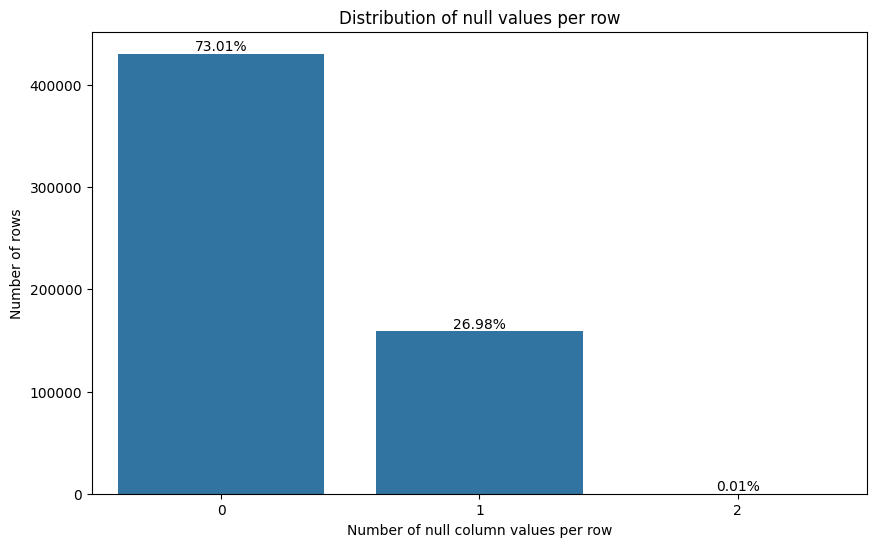

In [220]:
# compute the number of null values for each row
placements['null_count'] = placements.isnull().sum(axis=1)

plt.figure(figsize=(10, 6))
#ax=sbn.displot(placements['null_count'], bins="sturges")
ax=sbn.countplot(x='null_count', data=placements, legend=False)
total = len(placements['null_count'])

#% over the bars
for p in ax.patches:
    height = p.get_height()  #height of the bar
    percentage = 100 * height / total  #determine the %
    ax.text(
        p.get_x() + p.get_width() / 2,  #Position the text in the middle of the bar
        height,  #Position on the bar end
        f'{percentage:.2f}%',  # Mostriamo la percentuale con 1 decimale
        ha='center',           # Horizontal alignment
        va='bottom'            # Vertical alignment
    )

plt.title('Distribution of null values per row')
plt.xlabel('Number of null column values per row')
plt.ylabel('Number of rows')

plt.show()
plt.close()

We show the rows with the highest number of null values

In [221]:
max_null_count = placements['null_count'].max()
rows_with_max_null = placements[placements['null_count'] == max_null_count]
print("Rows with the highest number of null values:")
display(rows_with_max_null)

Rows with the highest number of null values:


,position,cyclist,cyclist_age,cyclist_team,delta,date,_url,null_count
21373,96,antonio-zanini,NaN,NaN,805.0,1990-04-01 07:00:50,ronde-van-vlaanderen/1990/result,2
27825,57,filippo-simonetti,NaN,NaN,5.0,1997-04-16 05:07:05,la-fleche-wallone/1997/result,2
30230,42,alexandr-osipov,NaN,NaN,276.0,1985-05-05 00:39:30,vuelta-a-espana/1985/stage-12,2
30246,58,sergei-jermachenko,NaN,NaN,327.0,1985-05-05 00:40:21,vuelta-a-espana/1985/stage-12,2
30249,61,vladimir-malakov,NaN,NaN,331.0,1985-05-05 00:40:25,vuelta-a-espana/1985/stage-12,2
...,...,...,...,...,...,...,...,...
540161,82,sergei-jermachenko,NaN,NaN,1814.0,1985-05-03 06:01:45,vuelta-a-espana/1985/stage-10,2
540173,94,alexandr-osipov,NaN,NaN,1814.0,1985-05-03 06:01:45,vuelta-a-espana/1985/stage-10,2
540203,124,nicolai-kosyakov,NaN,NaN,1814.0,1985-05-03 06:01:45,vuelta-a-espana/1985/stage-10,2
555652,86,antonio-zanini,NaN,NaN,2188.0,1990-04-08 08:13:30,paris-roubaix/1990/result,2


# Data distribution

Custom procedure that produces some basic statistics on a single feature of the dataset.

In [222]:
from distribution_utility import stats_and_distribution, show_stats, calculate_outlier_bounds
from cast_utility import cast_column_to_Int64, cast_column_to_string

## Features casting
### - float64 -> Int64 (which allows to correctly manage also Nan values)
### - object -> string (from pandas 1.0)
### - bool -> Int64

Before doing the casting from float64 to Int64, we make sure that the result is equal to the previous value

## cyclist_age

cyclist_age is a continuous attribute. The float64 column can be cast to int as the unique values are not decimal.

In [223]:
# We use 'Int64' to correctly manage also NaN values
cast_column_to_Int64(placements, 'cyclist_age')

Column casted from float64 to Int64


Description of attribute 'cyclist_age':


count     589752.0
mean     28.486208
std       3.855631
min           13.0
25%           26.0
50%           28.0
75%           31.0
max           56.0
Name: cyclist_age, dtype: Float64


Unique values:
<IntegerArray>
[  22,   27,   24,   30,   26,   36,   23,   32,   31,   28,   29,   21,   25,
   35,   38,   39,   34,   37,   33,   40,   20,   19, <NA>,   42,   41,   44,
   43,   45,   56,   13]
Length: 30, dtype: Int64

Null values: 113 over 589865 records - (0.02%)

Top 5 common value:
cyclist_age
27    58897
26    57921
28    56213
25    54346
29    52616
Name: count, dtype: Int64


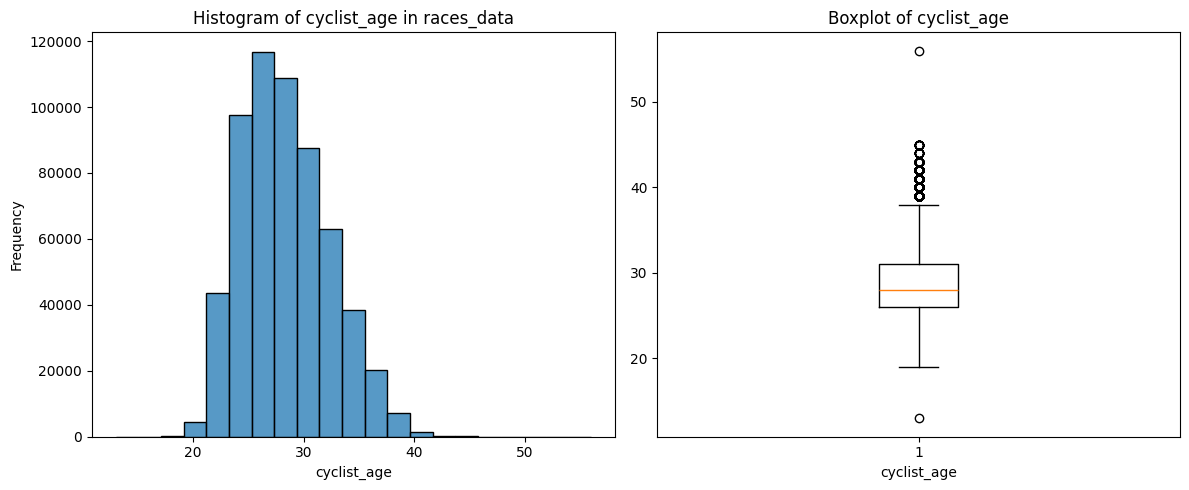

Outliers in cyclist_age: [np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(13), np.int64(45), np.int64(56)]


In [224]:
stats_and_distribution(placements, "cyclist_age", attr_type='numerical')

The histogram of ages shows a distribution similar to a Gaussian curve, with a peak around the mean of 28 years old. This confirms our expectations, as in cycling races, most participants are around the average age, with only a few straying far from it. Indeed, we notice a symmetric decrease in frequencies as we move away from the central age, highlighting that cyclists are mostly between 25 and 35 years old.
The boxplot marks as outliers all the placements of cyclists older than 38. We can notice two extreme outliers regarding at the ages of 13 and 56. These values can be considered as simple outliers or as errors; further investigations on that will be provided in the next sections.

The presence of 113 missing values can be mitigated using the information in the "cyclists" dataset.

## date
We convert date into datetime format, but since we are not interested in time information, we set it to midnight.

The _date_ feature is numeric continuos attribute. It represents the timestamp of the race start. For our purposes the time is irrelevant, so the column can be cast to 'date'. <br>

In [225]:
#Convertion of the object column to datetime64 (There are no missing values)
placements['date_no_cast'] = placements['date']
placements['date'] = pd.to_datetime(placements['date']).dt.floor('d')
print(placements['date'].dtype)

datetime64[ns]


In [226]:
show_stats(placements, 'date')

Description of attribute 'date':


count                           589865
mean     2006-08-11 17:59:28.544666880
min                1970-02-28 00:00:00
25%                1999-07-18 00:00:00
50%                2008-05-03 00:00:00
75%                2015-08-29 00:00:00
max                2023-07-29 00:00:00
Name: date, dtype: object


Unique values:
<DatetimeArray>
['1978-07-05 00:00:00', '2016-09-03 00:00:00', '2019-07-28 00:00:00',
 '1999-06-17 00:00:00', '2022-07-10 00:00:00', '2017-09-09 00:00:00',
 '1978-07-14 00:00:00', '2018-03-25 00:00:00', '1981-09-05 00:00:00',
 '1994-03-13 00:00:00',
 ...
 '2017-07-29 00:00:00', '2014-05-20 00:00:00', '1982-07-25 00:00:00',
 '2016-07-24 00:00:00', '2010-07-11 00:00:00', '2017-05-07 00:00:00',
 '2000-04-10 00:00:00', '1976-03-09 00:00:00', '2016-03-27 00:00:00',
 '2010-05-08 00:00:00']
Length: 4708, dtype: datetime64[ns]

Null values: 0 over 589865 records - (0.00%)

Top 5 common value:
date
1998-06-18    407
1987-07-05    404
2006-05-15    379
2006-05-16    377
2023-02-25    376
Name: count, dtype: int64


To present a meaningful graph, we've decided to group the data into 2-year intervals and create a bar plot on this group. This manual binning technique provides a clearer visual representation of the event counts over time, making it easier to identify trends and patterns.

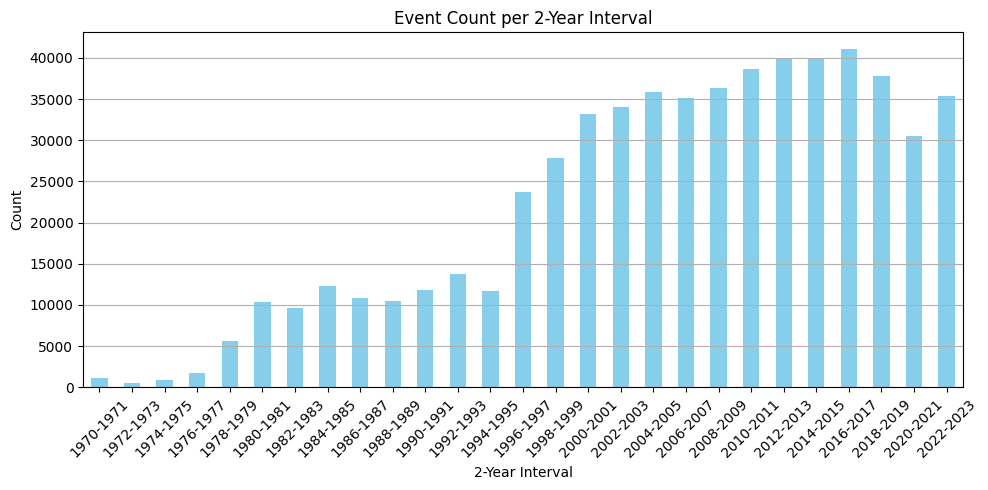

In [227]:
# Group by 4-year intervals
placements['year'] = placements['date'].dt.year
placements['year_group'] = (placements['year'] // 2) * 2  # Round the year to the nearest multiple of 4

# Count occurrences for each 4-year interval
year_counts = placements.groupby('year_group').size()

# Create labels for 4-year intervals
year_labels = [f"{year}-{year+1}" for year in year_counts.index]

# Create the bar plot
plt.figure(figsize=(10, 5))
year_counts.plot(kind="bar", color='skyblue')
plt.title('Event Count per 2-Year Interval')
plt.xlabel('2-Year Interval')
plt.ylabel('Count')
plt.xticks(ticks=range(len(year_labels)), labels=year_labels, rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## position
The position is a numeric ordinal attribute. It represents the finish position of the cyclist in the race event described by that row.


In [228]:
# We use 'Int64' to correctly manage also NaN values
print(placements['position'].dtype)

int64


Description of attribute 'position':


count     589865
unique       210
top            0
freq        5281
Name: position, dtype: int64


Unique values:
[0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27
 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51
 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75
 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99
 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117
 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135
 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153
 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171
 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189
 190 191 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207
 208 209]

Null values: 0 over 589865 records - (0.00%)

Top 5 common value:
position
0    5281
1    5275
2    5273
3    5267
4    5255
Name: count, dtype: int64


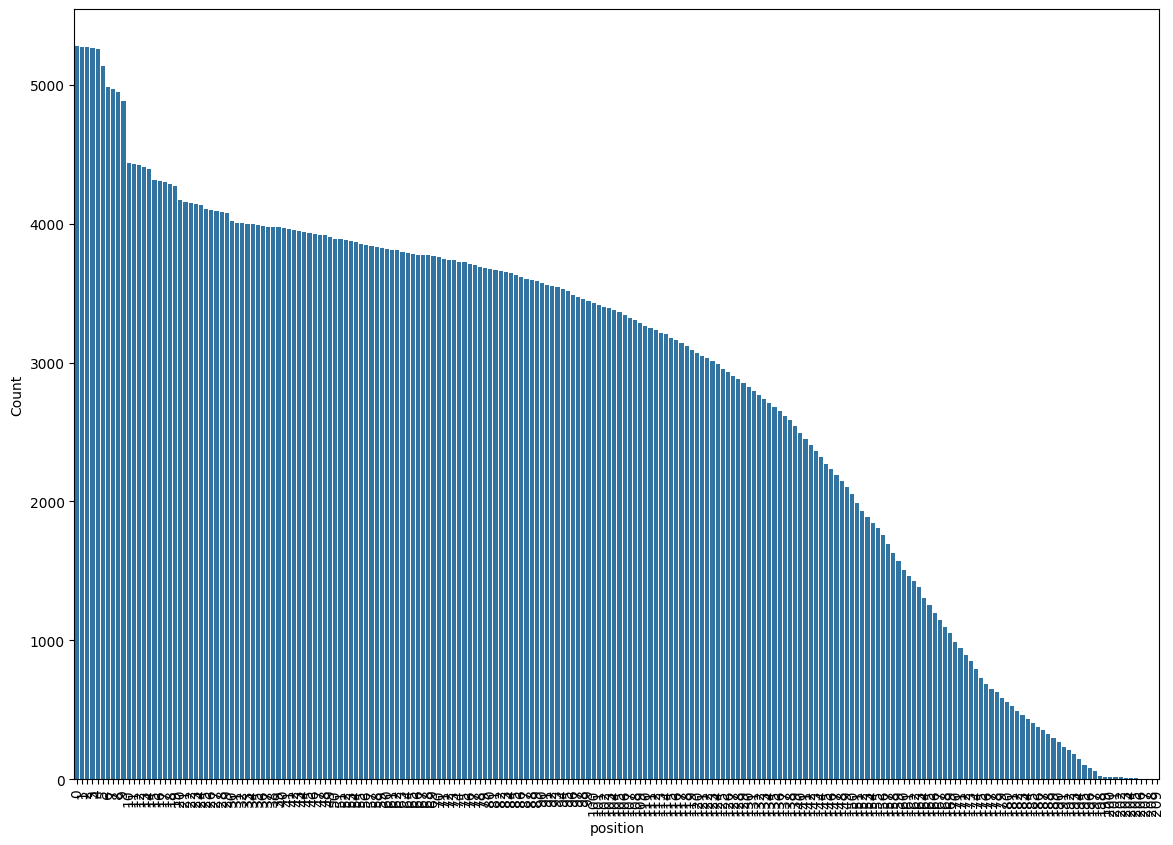

In [229]:
stats_and_distribution(placements, "position", attr_type='categorical')

From the listing of the unique values we can see that the maximum number of participants to a race event in the dataset is 209.

## cyclist and nationality
The cyclist is a categorical attribute that represents the reference to the cyclists that has obtained the placement. It is valued as _name-surname_.
We convert it from object to pandas string

In [230]:
cast_column_to_string(placements, 'cyclist')

Column casted from object to string


In [231]:
show_stats(placements, 'cyclist', attr_type='categorical')

Description of attribute 'cyclist':


count             589865
unique              6095
top       matteo-tosatto
freq                 959
Name: cyclist, dtype: object


Unique values:
['sean-kelly' 'gerrie-knetemann' 'rene-bittinger' ... 'jon-ander-insausti'
 'carlos-melero' 'roland-smet']

Null values: 0 over 589865 records - (0.00%)

Top 5 common value:
cyclist
matteo-tosatto        959
alejandro-valverde    942
luis-leon-sanchez     899
haimar-zubeldia       883
imanol-erviti         883
Name: count, dtype: int64


To create a more descriptive graph, we've decided to group cyclists by nationality.

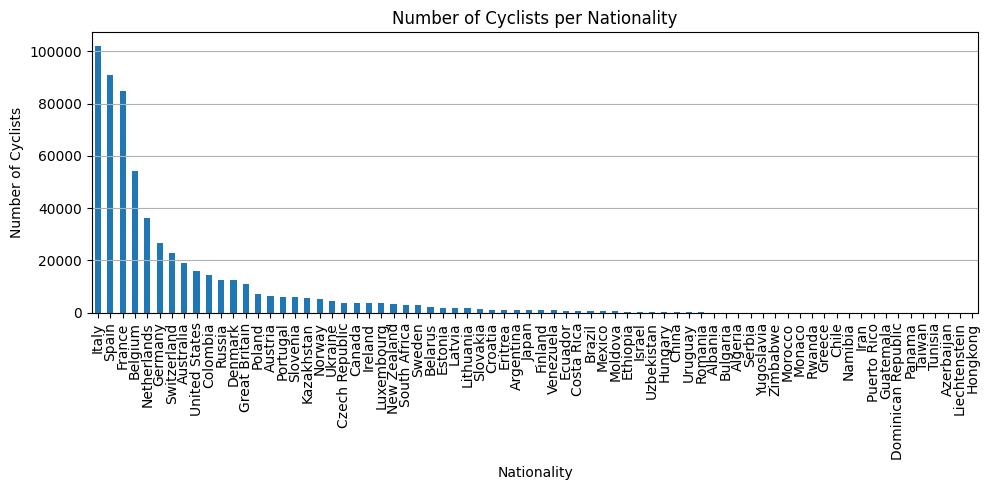

In [232]:
merged_df = pd.merge(left=placements, right=cyclists,left_on='cyclist', right_on='_url')

# Group by nationality
nationality_group = merged_df.groupby('nationality').size().sort_values(ascending=False)
# Create a bar plot of the grouping
plt.figure(figsize=(10, 5))
nationality_group.plot(kind='bar')
plt.title('Number of Cyclists per Nationality')
plt.xlabel('Nationality')
plt.ylabel('Number of Cyclists')
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.tight_layout()

This grouping reveals that many cyclists are French, Italian, or Spanish, suggesting that cycling is more popular in these countries. This popularity could be influenced by the presence of many prestigious races held in these areas.

## cyclist_team
We convert it from object to pandas string

In [233]:
cast_column_to_string(placements, 'cyclist_team')

Column casted from object to string


Description of attribute 'cyclist_team':


count                              430704
unique                                 91
top       liberty-seguros-wurth-team-2005
freq                                 8869
Name: cyclist_team, dtype: object


Unique values:
['vini-ricordi-pinarello-sidermec-1986' 'norway-1987' <NA>
 'navigare-blue-storm-1993' 'spain-1991' 'kelme-costa-blanca-2000'
 'japan-2008' 'ville-de-charleroi-new-systems-2000' 'switzerland-1997'
 'germany-2004' 'hungary-2002' 'radio-popular-paredes-boavista-2023'
 'new-zealand-1991' 'canada-1996' 'linea-md-italia-maggi-mobili-1985'
 'kazakhstan-2019' 'kondor-1979' 'mexico-1986' 'spar-rdm-1999'
 'o.n.c.e.-deutsche-bank-2000' 'rally-cycling-2021'
 'euskaltel-euskadi-2010' 'ceramica-panaria-navigare-2007'
 'united-states-1998' 'carlos-cycles-1975' 'ireland-2005'
 'team-saxo-bank-tinkoff-bank-2012' 'south-africa-1993'
 'liberty-seguros-wurth-team-2005' 'del-tongo-1986'
 'team-giant-shimano-2014' 'bora-hansgrohe-2021' 'france-1978'
 'australia-1991' 'teka-1988' 'cantanhede-marques-de-marialva-2003'
 'jolly-ceramica-1977' 'canada-2020' 'netherlands-1974' 'atala-1985'
 'czechoslovakia-1987' 'carrera-inoxpran-1985' 'luxembourg-2013'
 'denmark-1991' 'euskaltel-euskadi-2012' 'c

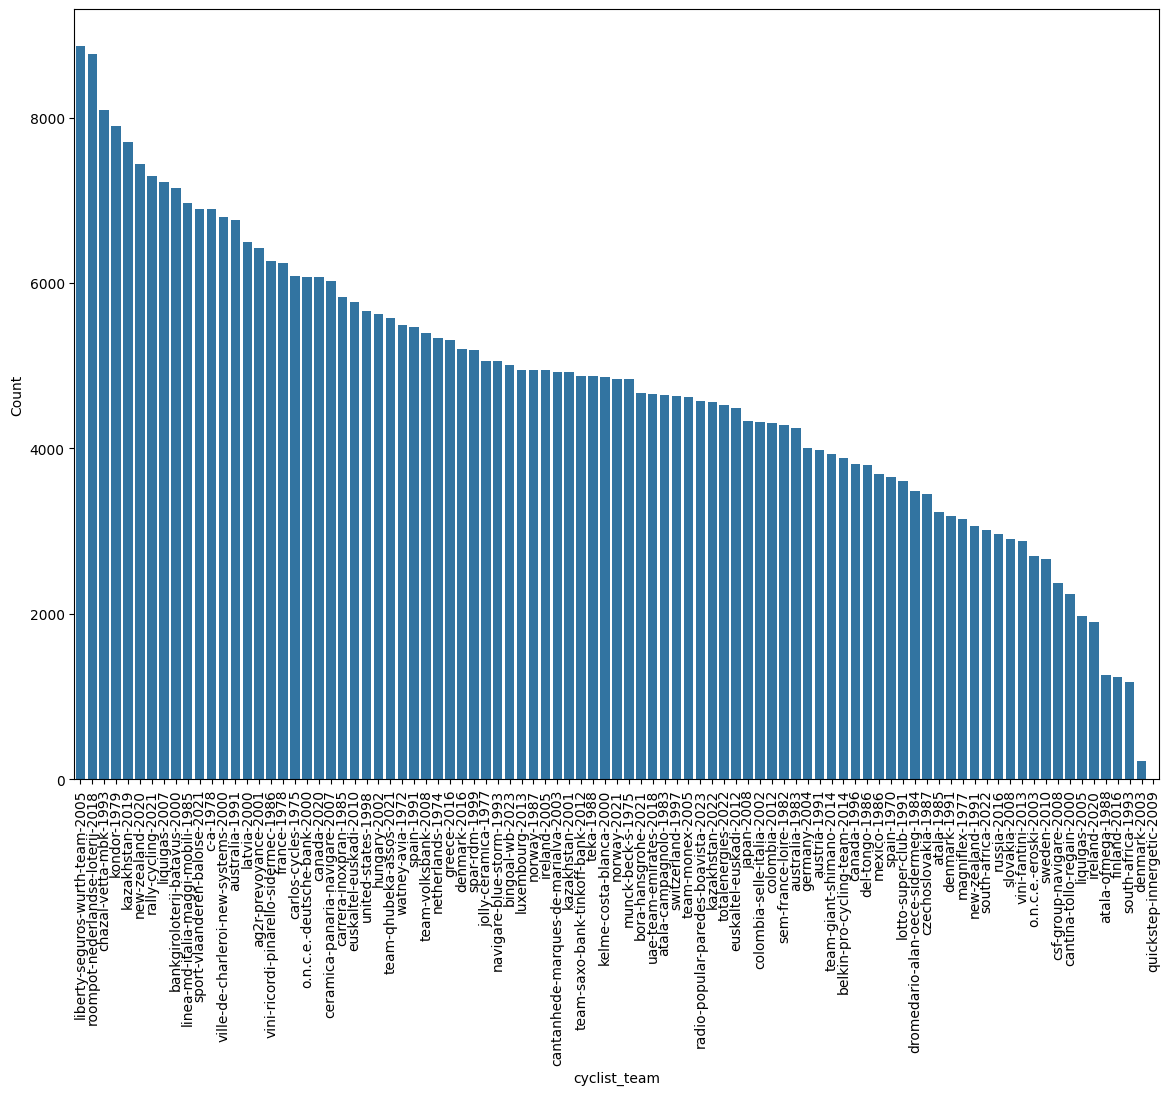

In [234]:
stats_and_distribution(placements, 'cyclist_team', attr_type='categorical')

We've observed that the teams are described as 'teamname-year'. To create a clearer representation, we'll remove the year and generate a bar plot focusing solely on the team names.

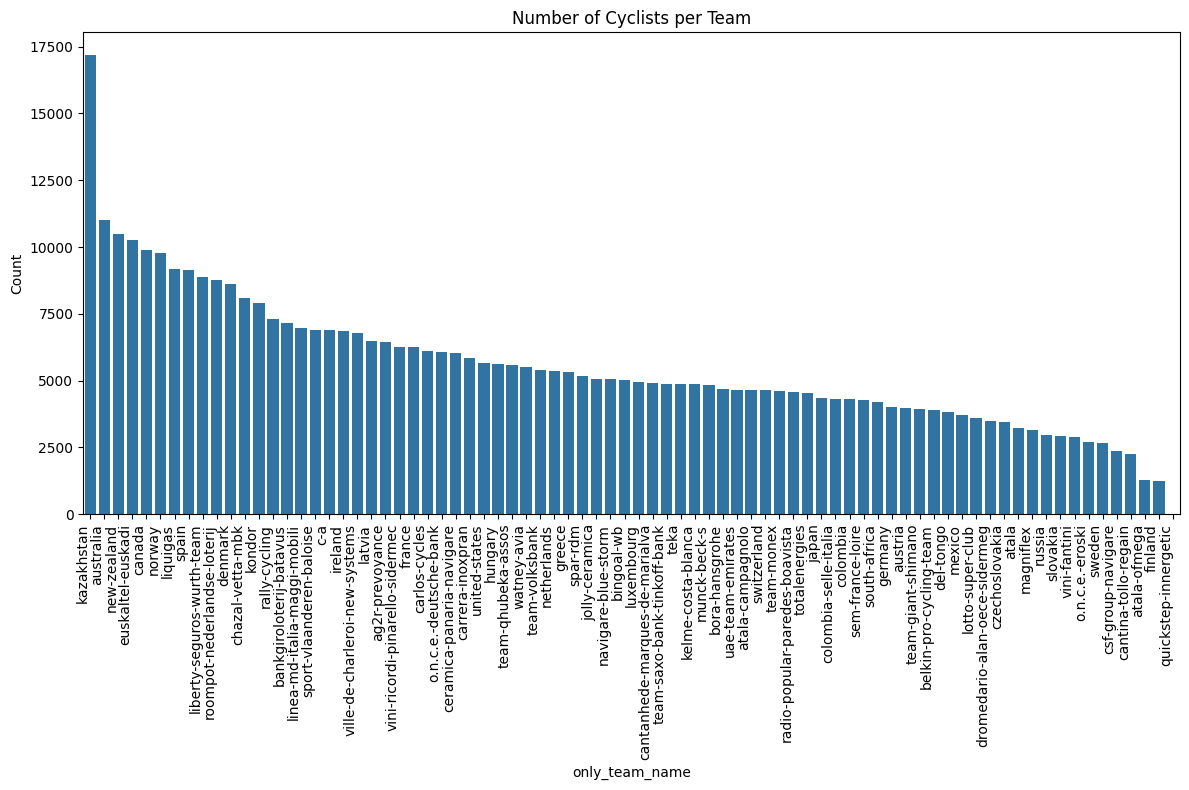

In [235]:
team_names = placements['cyclist_team'].dropna().apply(lambda x: '-'.join(x.split('-')[:-1]))
team_names_count = team_names.value_counts()

plt.figure(figsize=(12,8))
sbn.barplot(x= team_names_count.index, y= team_names_count.values)
plt.title('Number of Cyclists per Team')
plt.xlabel('only_team_name')
plt.ylabel('Count')
plt.xticks(rotation=90, ha='right')  # Rotate labels and align them horizontally
plt.tight_layout()  # Adjust layout to ensure everything fits without overlapping
plt.show()


We've observed that the team names in our dataset consist of both nationalities and specific cycling team names. The presence of nationalities like 'Kazakhstan' suggests national level competitions, while names like 'Quickstep-Innergetic' highlight the participation of professional cycling teams in races. This indicates a distinction between national events and professional team-based races. This dual representation highlights the diversity of cycling events, capturing both national pride and professional competitiveness.

## delta
Delta is a numeric continuous attribute. It represents the delay in arrival of this cyclist compared to the first placed cyclist. Its type can be cast to int since there are no decimals.

In [236]:
# We use 'Int64' to correctly manage also NaN values
cast_column_to_Int64(placements, 'delta')

Column casted from float64 to Int64


Description of attribute 'delta':


count      589865.0
mean     418.292794
std      842.961596
min         -6906.0
25%            10.0
50%           156.0
75%           624.0
max         61547.0
Name: delta, dtype: Float64


Unique values:
<IntegerArray>
[    0,    27,    64,     7,     9,    31,    39,    49,    71,    74,
 ...
  3108,  3136,  3162,  3200,  3259,  3432,  3434, 24264, 34523, 34522]
Length: 2836, dtype: Int64

Null values: 0 over 589865 records - (0.00%)

Top 5 common value:
delta
0    120546
2      3700
5      3353
3      3178
4      3036
Name: count, dtype: Int64


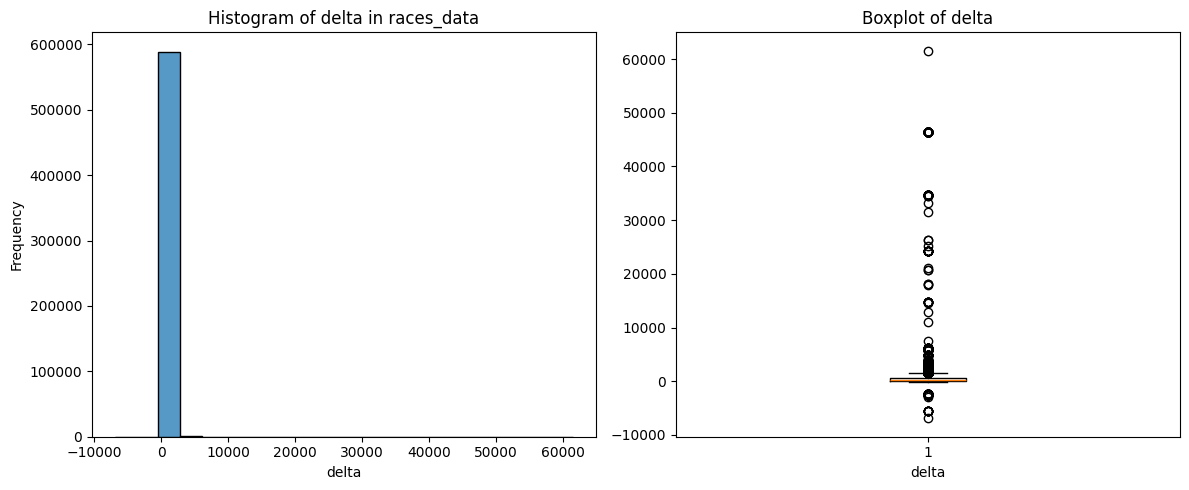

Outliers in delta: [np.int64(34522), np.int64(34523), np.int64(33140), np.int64(1751), np.int64(25223), np.int64(1770), np.int64(-6906), np.int64(1927), np.int64(1546), np.int64(1547), np.int64(1548), np.int64(1549), np.int64(1550), np.int64(1551), np.int64(1552), np.int64(1553), np.int64(1554), np.int64(1555), np.int64(1556), np.int64(1557), np.int64(1558), np.int64(1559), np.int64(1560), np.int64(1561), np.int64(1562), np.int64(1563), np.int64(1564), np.int64(1565), np.int64(1566), np.int64(1567), np.int64(1568), np.int64(1569), np.int64(1570), np.int64(1571), np.int64(1572), np.int64(1573), np.int64(1574), np.int64(1575), np.int64(1576), np.int64(1577), np.int64(1578), np.int64(1579), np.int64(1580), np.int64(1581), np.int64(1582), np.int64(1583), np.int64(1584), np.int64(1585), np.int64(1586), np.int64(1587), np.int64(1588), np.int64(1589), np.int64(1590), np.int64(1591), np.int64(1592), np.int64(1593), np.int64(1594), np.int64(1595), np.int64(1596), np.int64(1597), np.int64(1598),

In [237]:
stats_and_distribution(placements, 'delta', attr_type='numerical')

The distribution of delta indicates that the data is highly skewed, with most competitors finishing close to the first-place finisher. However, there are a small number of participants with significantly higher delta values, creating a long tail in the distribution. This pattern may reflect the variability in event types and course difficulties.

In [238]:
# da completare se serve

upper_value = calculate_outlier_bounds(placements, "delta")['upper']
(placements[placements['delta'] > upper_value]['_url'].value_counts() > 100).sum()

np.int64(61)

# Data quality

### Age

The box plot for this attribute showed the presence of several outliers, particularly those ages over 38. Our analysis focused on two of them, with values of 13 and 56 respectively, which are very different from the other values. In particular, we tried to investigate whether these values could be erroneous or legitimate outliers. 

In [239]:
placements[(placements['cyclist_age'] == 13) | (placements['cyclist_age'] == 56)]


,position,cyclist,cyclist_age,cyclist_team,delta,date,_url,null_count,date_no_cast,year,year_group
114525,129,jose-azevedo-goncalves,56,<NA>,0,1996-09-07,vuelta-a-espana/1996/stage-1,1,1996-09-07 03:52:27,1996,1996
294489,91,plamen-stanev,13,<NA>,663,2001-08-11,san-sebastian/2001/result,1,2001-08-11 05:28:57,2001,2000


Given that the ‘cyclists’ dataset shows the year of birth of the cyclist ‘planem-stanev’ (1988), and that the only race he took part in was held in 2001, consequently the age (13) he was in that race matches with the age in the 'races' dataset. So we are not able to affirm that the age 13, which seems an error because typically it's required to be of legal age to take part in a professional cycling race, is actually an error to be discarded.

#### Check the age consistency between the two datasets

Below we verify that there is consistency between the year of birth in the “cyclists” dataset and the age during race participation in the “placements” dataset.

In [240]:
placements.head()

,position,cyclist,cyclist_age,cyclist_team,delta,date,_url,null_count,date_no_cast,year,year_group
0,0,sean-kelly,22,vini-ricordi-pinarello-sidermec-1986,0,1978-07-05,tour-de-france/1978/stage-6,0,1978-07-05 04:02:24,1978,1978
1,1,gerrie-knetemann,27,norway-1987,0,1978-07-05,tour-de-france/1978/stage-6,0,1978-07-05 04:02:24,1978,1978
2,2,rene-bittinger,24,<NA>,0,1978-07-05,tour-de-france/1978/stage-6,1,1978-07-05 04:02:24,1978,1978
3,3,joseph-bruyere,30,navigare-blue-storm-1993,0,1978-07-05,tour-de-france/1978/stage-6,0,1978-07-05 04:02:24,1978,1978
4,4,sven-ake-nilsson,27,spain-1991,0,1978-07-05,tour-de-france/1978/stage-6,0,1978-07-05 04:02:24,1978,1978


In [241]:
cyclists_df = pd.read_csv('../dataset/cyclists.csv')
cyclists_df.head()


,_url,name,birth_year,weight,height,nationality
0,bruno-surra,Bruno Surra,1964.0,NaN,NaN,Italy
1,gerard-rue,Gérard Rué,1965.0,74.0,182.0,France
2,jan-maas,Jan Maas,1996.0,69.0,189.0,Netherlands
3,nathan-van-hooydonck,Nathan Van Hooydonck,1995.0,78.0,192.0,Belgium
4,jose-felix-parra,José Félix Parra,1997.0,55.0,171.0,Spain


**Get the cyclists from the two datasets**

In [242]:
cyclists_placements = placements['cyclist'].unique()
cyclists_placements_count = len(cyclists_placements)


In [243]:
cyclists_uniques = cyclists_df['_url'].unique()
cyclists_unique_count = len(cyclists_uniques)
if (len(cyclists_df['_url']) == cyclists_unique_count):
    print("Correctly each cyclist url appears only one time in the cyclists dataset as row")


Correctly each cyclist url appears only one time in the cyclists dataset as row


**Comparison of the number of cyclists** <br>
We can see that 'cyclists' dataset contains 39 more cyclists than 'placements' dataset.

In [244]:
print(f"Number of unique cyclists in the cyclists dataset: {cyclists_unique_count}\
      \nNumber of unique cyclists in the placements dataset: {cyclists_placements_count}")

Number of unique cyclists in the cyclists dataset: 6134      
Number of unique cyclists in the placements dataset: 6095


Let's see the list of different cyclists between the two datasets.

In [245]:
diff = np.setxor1d(cyclists_uniques, cyclists_placements)
print(f"{len(diff)} different cyclists between the two datasets:\n {diff}")


39 different cyclists between the two datasets:
 ['arturo-gravalos-lopez' 'bas-tietema' 'benjamin-levecot'
 'christian-mager' 'christophe-premont' 'dorian-de-maeght'
 'eddy-torrekens' 'eric-schoefs' 'flavio-cardoso' 'franck-morelle'
 'gert-van-brabant' 'gianluca-maggiore' 'gino-primo' 'hiroki-nishimura'
 'jean-michel-thilloy' 'jeanot-deriemaecker' 'koen-hullebusch'
 'kurt-van-landeghem' 'lenaic-olivier' 'luca-braidot' 'marat-ganeev'
 'martin-gilbert' 'matteo-di-serafino' 'mattia-bevilacqua' 'mattia-viel'
 'morten-hegreberg' 'nicolas-liboreau' 'oleg-grishkine' 'olivier-matthys'
 'pascal-duez' 'peter-spaenhoven' 'philipp-ludescher' 'raphael-pires'
 'rik-claeys' 'rikkie-matthijssens' 'roman-bronis'
 'sergio-garcia-gonzalez' 'silvere-ackermann' 'tanner-putt']


For what concerns the field 'birth_year' in the cyclist data set, we are going to transform it from float to int, because here we only have the information of the year. 

In [246]:
print(cyclists_df['birth_year'].dtype)
#by using Int64 we don't get errors due to the presence of Nan
cyclists_df['birth_year'] = cyclists_df['birth_year'].astype('Int64')

print(cyclists_df['birth_year'].head())
print(cyclists_df['birth_year'].dtype)  


float64
0    1964
1    1965
2    1996
3    1995
4    1997
Name: birth_year, dtype: Int64
Int64


The 'cyclist_age' field is cast from float to Int64.

In [247]:
print(placements['cyclist_age'].dtype)
placements['cyclist_age'] = placements['cyclist_age'].astype('Int64')

print(placements['cyclist_age'].head())
print(placements['cyclist_age'].dtype)  

Int64
0    22
1    27
2    24
3    30
4    27
Name: cyclist_age, dtype: Int64
Int64


**Merging datasets on the same cyclist**

In [248]:
merged_df = pd.merge(cyclists_df, placements, left_on='_url', right_on='cyclist', how='inner')
print(merged_df.shape)
print(merged_df[['birth_year', 'cyclist_age', 'date']])
# write in a temporary file for offline checking
merged_df.to_csv('../dataset/merged_df_temp.csv', index=False)

(589865, 17)
        birth_year  cyclist_age       date
0             1964           25 1989-04-24
1             1965           32 1997-07-07
2             1965           25 1990-07-01
3             1965           27 1992-07-11
4             1965           25 1990-07-09
...            ...          ...        ...
589860        1999           23 2022-04-17
589861        1999           23 2022-03-30
589862        1999           24 2023-03-24
589863        1999           24 2023-02-25
589864        1999           22 2021-03-26

[589865 rows x 3 columns]


**Verify the age consistency** <br>
We do this by calculating the expected age at the race moment, and then comparing this age with the one indicated in the placements dataset.
We do this step for each row, so for each cyclist and all the stages of all races in which he participated.

If even only one among these fields: birth_year, cyclist_age, date, is not valued, we'll skip the corresponding row.

As we can see, we get a truly consistency between the ages indicated into the two dataset

In [249]:
df_filtered = merged_df.dropna(subset=['birth_year', 'date', 'cyclist_age']).copy()

# we regard only on race year
df_filtered['date'] = df_filtered['date'].dt.year

df_filtered['expected_age'] = df_filtered['date'] - df_filtered['birth_year']

df_filtered['consistent_age'] = (df_filtered['cyclist_age'] == df_filtered['expected_age'])

print(df_filtered['consistent_age'].all())

df_filtered.to_csv('../dataset/df_for_age_consistency.csv', index=False)


True


### Delta 

This feature should indicate the delay in seconds, of the cyclist represented in the row, in relation to the first classified in that race event.
However, there are some negative delta values and, in addition, the first classifiers of some races may have a delta value different from zero.
It seems that there is an inconsistency between the semantics of this column and the real values it contains. In fact a delay from the first classified should not be less than zero and the delay of the first classifier should be zero!

In [250]:
neg = placements[placements['delta'] < 0]
len(neg)

86

Let's check if a negative delta could be an error or it is related to a particular race.

In [251]:
pd.set_option('display.max_rows', None)


In [252]:
neg[['_url', 'delta', 'position']]

,_url,delta,position
70651,vuelta-a-espana/1992/stage-19,-2635,10
70652,vuelta-a-espana/1992/stage-19,-2638,11
70653,vuelta-a-espana/1992/stage-19,-2541,12
70654,vuelta-a-espana/1992/stage-19,-2542,13
70655,vuelta-a-espana/1992/stage-19,-2545,14
70656,vuelta-a-espana/1992/stage-19,-2546,15
70657,vuelta-a-espana/1992/stage-19,-2550,16
70658,vuelta-a-espana/1992/stage-19,-2560,17
70659,vuelta-a-espana/1992/stage-19,-2564,18
70660,vuelta-a-espana/1992/stage-19,-2567,19


We can see that the negative 'delta' are mostly related to the same race event (whose url is _vuelta-a-espana/1992/stage-19_). There are also few (9) anomalous values for the race event _paris-nice/1990/stage-7a_. Let's check if all rows of _vuelta-a-espana/1992/stage-19_ have the same problem with the 'delta'. 

In [253]:
placements[placements['_url'] =='vuelta-a-espana/1992/stage-19'][['position', 'delta','cyclist']]

,position,delta,cyclist
70641,0,0,tony-rominger
70642,1,52,eric-vanderaerden
70643,2,68,erik-breukink
70644,3,93,marco-giovannetti
70645,4,100,fabio-enrique-parra
70646,5,101,pedro-delgado
70647,6,109,jesus-montoya
70648,7,113,thomas-wegmuller
70649,8,119,arturas-kasputis
70650,9,125,stephen-hodge


Also the external trustable information sources report this problem with the recorded value of the delta. [Source](https://www.procyclingstats.com/race/vuelta-a-espana/1992/stage-19)

By consulting external sources, we have discovered that in some important placements, such as the _Vuelta a España_, there could be some bonuses in terms of delta time for the cyclists placed in the first positions. This bonus is subtracted from the final time, so some rows may have a negative delta. Often these bonuses are related to extremely good performances in some intermediate sprints, such as impegnative hills, compared to the leader of the race event or to the cyclists standing.

However, it seems that in some races the delta value does not have the monotonically increasing behaviour that we would expect. For this reason we are trying to check if other races have this anomalous behaviour and if it is possible to correct this problem.

In [254]:
placements[placements['_url'] =='paris-nice/1990/stage-7a'][['position', 'delta','cyclist']]

,position,delta,cyclist
229663,0,0,mauro-ribeiro
229664,1,-5562,charly-mottet
229665,2,-5562,adriano-baffi
229666,3,-5562,maximilian-sciandri
229667,4,-5562,johan-museeuw
229668,5,-5562,federico-ghiotto
229669,6,-5562,francis-moreau
229670,7,-5562,laurent-jalabert
229671,8,-5562,claudio-chiappucci
229672,9,-6906,jean-claude-colotti


We notice that for this race (_paris-nice/1990/stage-7a_) there are only 10 competitors and all of them, except the first classified, have a negative Delta value. In this case, we can try to reconstruct the correct value for the delta and estimate a time bonus of 5500. In any case, the riders in 2nd and 9th place will all have the same delta. There may be other problems with this column.

In [255]:
placements[placements['_url'] =='tour-de-france/2003/stage-12'][['position', 'delta','cyclist']]

,position,delta,cyclist
413388,0,0,jan-ullrich
413389,1,96,lance-armstrong
413390,2,126,alexandre-vinokourov
413391,3,160,haimar-zubeldia
413392,4,163,tyler-hamilton
413393,5,206,uwe-peschel
413394,6,235,david-millar
413395,7,241,inigo-chaurreau-bernardez
413396,8,277,david-plaza-romero
413397,9,300,santiago-botero


As we can see in this race (_tour-de-france/2003/stage-12_) there is only one participant with an anomalous value for the delta, the one in position 104. We notice that the cyclists in position 102 and  position 103 have the same delta (563.0) value. We can assume that this anomalous value could be an error and the 104th is arrived at the same time of the 102th and the 103th classified.

In [256]:
placements.loc[413492, 'delta']

np.int64(-2937)

In [257]:
placements.loc[413492, 'delta'] = 563

In [258]:
placements.loc[413492, 'delta']

np.int64(563)

In [259]:
placements[placements['_url'] =='tour-de-suisse/1993/stage-4'][['position', 'delta','cyclist']]

,position,delta,cyclist
520734,0,0,pavel-tonkov
520735,1,-106,marco-saligari
520736,2,58,zenon-jaskula
520737,3,19,fabio-casartelli
520738,4,19,beat-zberg
520739,5,19,gerd-audehem


In this case we found values that are completely strange. The second classified has a negative delta while the 4th-5th-6th have a delta lower than the 2nd classified! 

In [260]:
pd.reset_option('display.max_rows')

In [261]:
placements[(placements['position'] == 0) & (placements['delta'] != 0)]

,position,cyclist,cyclist_age,cyclist_team,delta,date,_url,null_count,date_no_cast,year,year_group


As expected, all cyclists in position 0 (first classified) have a delta of 0. However, there are many zero deltas, even for cyclists in different positions. We could try to reconstruct the values for this column by looking for groups of cyclists who arrived at the same time. Note that this problem affects 115265 (about 1/6). Perhaps it would be more reasonable to discard this column and keep the "position" that gave us the final arrival order.

In [262]:
placements[(placements['delta']==0) & (placements['position']!=0)][['_url','delta','position']]

,_url,delta,position
1,tour-de-france/1978/stage-6,0,1
2,tour-de-france/1978/stage-6,0,2
3,tour-de-france/1978/stage-6,0,3
4,tour-de-france/1978/stage-6,0,4
272,tour-de-france/2019/stage-21,0,1
...,...,...,...
589538,paris-nice/1976/stage-2,0,75
589539,paris-nice/1976/stage-2,0,76
589540,paris-nice/1976/stage-2,0,77
589541,paris-nice/1976/stage-2,0,78


There are many rows for which the delta is zero but the position is not zero!

In [263]:
delta_groups=placements.groupby(['_url','delta']).size()
delta_groups

_url                            delta
amstel-gold-race/1970/result    0         2
                                22        1
                                33       14
                                52       17
                                72        1
                                         ..
world-championship/2022/result  623       2
                                688      12
                                700       1
                                868       1
                                905       2
Length: 140517, dtype: int64

We can see that there are groups of cyclists, even large groups, who arrive at the finish line at about the same time.

In [264]:
print(f"Max number of cyclists with the same delta in a race is {delta_groups.max()} occurred in {delta_groups.idxmax()}")

Max number of cyclists with the same delta in a race is 203 occurred in ('tour-de-france/1986/stage-1', np.int64(11))


Given the sematic of the column, we expect that the delta should have a monotonic increasing behavior since it represents the delay from the first classified.

#### Script to check that a numerical column has a monotonic increasing behavior

In [265]:
def is_monotonic_increasing(df, group_field, target_field):
    #Group the dataframe on the field specified as parameters
    groups = df.groupby(group_field)
    
    #Check the monotonicity and collect the groups for which the property is not satisfied
    non_monotonic = [
        name for name, group in groups 
        if not group[target_field].dropna().is_monotonic_increasing
    ]
    
    #Return the anomalous groups
    return non_monotonic

In [266]:
groupList=is_monotonic_increasing(placements,'_url', 'delta')
tot=placements.groupby('_url').ngroups
per=len(groupList)*100/tot
print(f"There are {len(groupList)} placements over {tot} ({(len(groupList) * 100 / tot):.2f}%) with not monotonic 'delta' values")

There are 345 placements over 5281 (6.53%) with not monotonic 'delta' values


In [267]:
print(f"There are {placements[placements['delta']==0].shape[0]} rows with a zero delta ({(placements[placements['delta']==0].shape[0] * 100 / placements.shape[0]):.2f}%)")


There are 120546 rows with a zero delta (20.44%)


#### Check the errors on the monotic behavior of the delta in each group

In [268]:
# new column to save error status
placements['delta_error'] = False

def check_monotonic_errors(group):
    # sort group by position
    group = group.sort_values(by='position')
    # compute the progressive maximum among all previous values ​​(except the current value)
    group['max_previous'] = group['delta'].cummax().shift(1)
    # check if each value is less than the maximum of the previous one
    group['delta_error'] = group['delta'] < group['max_previous']
    return group

# apply function to each group (grouped by _url)
placements = placements.groupby('_url').apply(check_monotonic_errors).reset_index(drop=True)

placements[placements['delta_error'] == True]

/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_86905/3598458473.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  placements = placements.groupby('_url').apply(check_monotonic_errors).reset_index(drop=True)


,position,cyclist,cyclist_age,cyclist_team,delta,date,_url,null_count,date_no_cast,year,year_group,delta_error,max_previous
10893,133,christophe-moreau,35,sweden-2010,323,2006-06-06,dauphine/2006/stage-2,0,2006-06-06 04:51:16,2006,2006,True,366
10901,141,jorg-ludewig,31,<NA>,323,2006-06-06,dauphine/2006/stage-2,1,2006-06-06 04:51:16,2006,2006,True,399
12610,16,ludovic-turpin,32,c-a-1978,37,2007-06-17,dauphine/2007/stage-7,0,2007-06-17 02:56:10,2007,2006,True,46
12852,2,bjorn-schroder,28,<NA>,4,2008-06-09,dauphine/2008/stage-2,1,2008-06-09 04:46:40,2008,2008,True,6
12853,3,fabian-wegmann,28,o.n.c.e.-eroski-2003,4,2008-06-09,dauphine/2008/stage-2,0,2008-06-09 04:46:40,2008,2008,True,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
584457,173,edoardo-zambanini,21,new-zealand-2020,0,2022-08-20,vuelta-a-espana/2022/stage-2,0,2022-08-20 03:49:34,2022,2022,True,142
584458,174,daryl-impey,38,slovakia-2008,0,2022-08-20,vuelta-a-espana/2022/stage-2,0,2022-08-20 03:49:34,2022,2022,True,142
584459,175,jan-hirt,31,carlos-cycles-1975,0,2022-08-20,vuelta-a-espana/2022/stage-2,0,2022-08-20 03:49:34,2022,2022,True,142
584460,176,gerben-thijssen,24,carlos-cycles-1975,0,2022-08-20,vuelta-a-espana/2022/stage-2,0,2022-08-20 03:49:34,2022,2022,True,142


This check proves that there are no negative values ​​in delta for rows that have no monotonicity errors (on delta)

In [269]:
placements[(placements['delta_error'] == False) & (placements['delta'] < 0)]

,position,cyclist,cyclist_age,cyclist_team,delta,date,_url,null_count,date_no_cast,year,year_group,delta_error,max_previous


Here, we check how the distribution changes by imputing the values ​​and determining the delta as the maximum between previous and next for each value


Description of attribute 'delta_log':


/Users/lorisgiunta/.pyenv/versions/3.12.4/lib/python3.12/site-packages/pandas/core/arrays/masked.py:672: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs2, **kwargs)
/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_86905/2926699817.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  correct_rows['delta_log'] = np.log(correct_rows['delta'].replace(0, np.nan))


count     467367.0
mean      5.354867
std       1.652106
min            0.0
25%       4.276666
50%       5.697093
75%       6.673298
max      11.027556
Name: delta_log, dtype: Float64


Unique values:
<FloatingArray>
[              <NA>,  3.091042453358316, 3.4965075614664802,
 3.9512437185814275,  4.276666119016055, 5.7899601708972535,
 4.5217885770490405,   4.61512051684126,  5.056245805348308,
  5.181783550292085,
 ...
 7.8547691834991324,  7.905072849498666,  7.906178840394815,
  7.906915488678587,  7.729735331385051,  7.780720886117918,
  7.781973234434385,  7.784057002639929,  7.805474625270857,
  7.813187267521416]
Length: 2761, dtype: Float64

Null values: 113979 over 581346 records - (19.61%)

Top 5 common value:
delta_log
0.693147    3624
1.609438    3295
1.098612    3163
1.791759    2971
1.386294    2858
Name: count, dtype: Int64


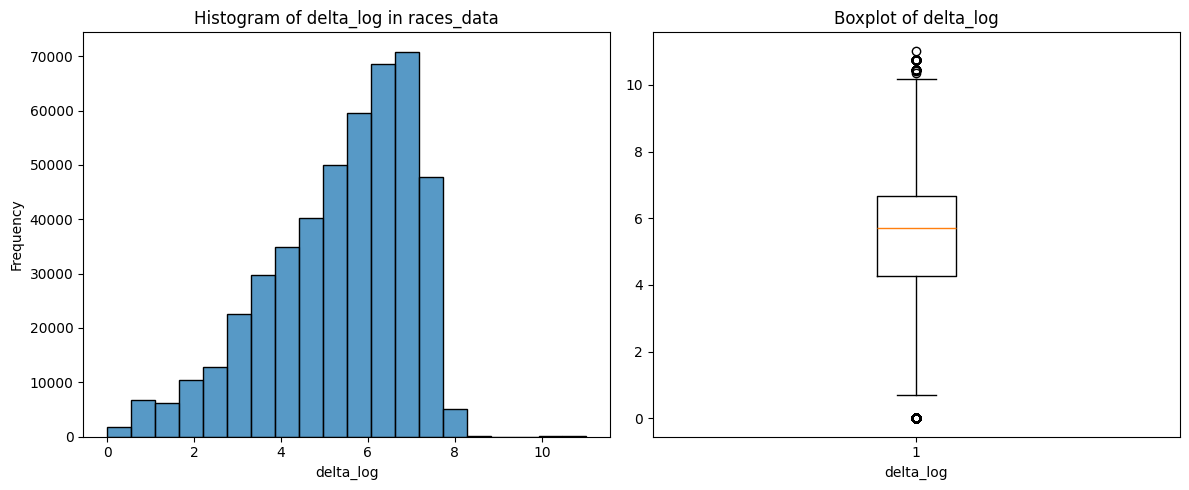

Outliers in delta_log: [np.float64(0.0), np.float64(10.408496290980555), np.float64(10.456165040324679), np.float64(10.355836246543143), np.float64(10.744623610809523), np.float64(10.449381047562612), np.float64(11.027556389563637)]
Description of attribute 'delta':


count      581346.0
mean     423.636014
std      844.261677
min             0.0
25%            13.0
50%           162.0
75%           633.0
max         61547.0
Name: delta, dtype: Float64


Unique values:
<IntegerArray>
[   0,   22,   33,   52,   72,  327,   92,  101,  157,  178,
 ...
 2578, 2711, 2714, 2716, 2275, 2394, 2397, 2402, 2454, 2473]
Length: 2761, dtype: Int64

Null values: 0 over 581346 records - (0.00%)

Top 5 common value:
delta
0    113979
2      3624
5      3295
3      3163
6      2971
Name: count, dtype: Int64


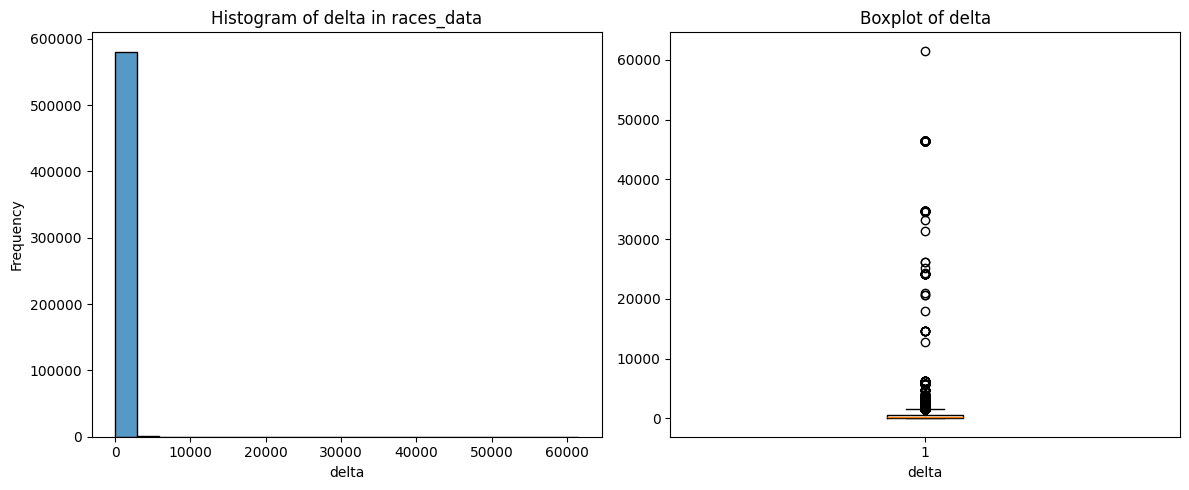

Outliers in delta: [np.int64(2048), np.int64(2049), np.int64(2050), np.int64(2051), np.int64(2052), np.int64(2053), np.int64(2054), np.int64(2055), np.int64(2056), np.int64(2057), np.int64(2058), np.int64(2059), np.int64(2060), np.int64(2061), np.int64(2062), np.int64(2063), np.int64(2064), np.int64(2065), np.int64(2066), np.int64(2067), np.int64(2068), np.int64(2069), np.int64(2070), np.int64(2071), np.int64(2072), np.int64(2073), np.int64(2074), np.int64(2075), np.int64(2076), np.int64(2077), np.int64(2078), np.int64(2079), np.int64(2080), np.int64(2081), np.int64(2082), np.int64(2083), np.int64(2084), np.int64(2085), np.int64(2086), np.int64(2087), np.int64(2088), np.int64(2089), np.int64(2090), np.int64(2091), np.int64(2092), np.int64(2093), np.int64(2094), np.int64(2095), np.int64(2096), np.int64(2097), np.int64(2098), np.int64(2099), np.int64(2100), np.int64(2101), np.int64(2102), np.int64(2103), np.int64(2105), np.int64(2106), np.int64(2107), np.int64(2108), np.int64(2109), np.i

In [270]:
correct_rows = placements[(placements['delta_error'] == False)]
correct_rows['delta_log'] = np.log(correct_rows['delta'].replace(0, np.nan))
stats_and_distribution(correct_rows, 'delta_log', attr_type='numerical')
stats_and_distribution(correct_rows, 'delta', attr_type='numerical')

#### Function to adjust errors of monotonic behavior

In [271]:
def adjust_monotonic_errors(group):
    group = group.sort_values(by='position')
    mask = group['delta_error'] == True
    # compute the progressive maximum between all previous values ​​and the next one
    correct_delta = group['delta'].cummax().shift(-1)
    # fill any NaN in the last value with the last valid value
    correct_delta = correct_delta.ffill() 
    # update delta only for rows where delta_error is True (mask==True), setting it to correct_delta to respect the progression.
    group.loc[mask, 'delta'] = correct_delta[mask]
    return group

placements = placements.groupby('_url').apply(adjust_monotonic_errors).reset_index(drop=True)

/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_86905/3180811619.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  placements = placements.groupby('_url').apply(adjust_monotonic_errors).reset_index(drop=True)


Let's now check if the correction was successful

In [272]:
monotonic_status = placements.groupby('_url')['delta'].apply(lambda x: x.is_monotonic_increasing)

print("All the groups are monotic increasing:",  monotonic_status.all())

All the groups are monotic increasing: True


In [273]:
placements = placements.drop('delta_error', axis=1)

### Position
By comparing our data with external sources of information, we noticed that the first classified in a race has a position of '0' rather than the '1' we would expect.

In [274]:
groupList=is_monotonic_increasing(placements,'_url', 'position')
tot=placements.groupby('_url').ngroups
per=len(groupList)*100/tot
print(f"There are {len(groupList)} placements over {tot} ({(len(groupList) * 100 / tot):.2f}%) with not monotonic 'position' values")

There are 0 placements over 5281 (0.00%) with not monotonic 'position' values


As expected, the position field takes monotonically increasing values for each race event. Let's check if there are anomalous position values (not consecutive).

In [275]:
def are_values_consecutive(df, group_field, target_field):
    #Group the dataframe on the field specified as parameters
    groups = df.groupby(group_field)
    
    #Check if the values for each group are consecutive and collect the groups for which the property is not satisfied
    non_consecutive = []
    
    for name, group in groups:
        #Sort the values of the target field for each group
        values = group[target_field].dropna().sort_values().reset_index(drop=True)
        
        #Check the differences between consecutive rows
        differences = values.diff().dropna() #for the first value there is a 'NaN' because there is nothing before to check
        
        if not (differences == 1).all():
            non_consecutive.append(name)
    
    ##Return the anomalous groups
    return non_consecutive

In [276]:
groupList=are_values_consecutive(placements,'_url', 'position')
tot=placements.groupby('_url').ngroups
per=len(groupList)*100/tot
print(f"There are {len(groupList)} placements over {tot} ({(len(groupList) * 100 / tot):.2f}%) with not consecutive positions")

There are 0 placements over 5281 (0.00%) with not consecutive positions


### date
Based on this analysis of the _date_ field, we cannot conclude that the date corresponds to the start date and time of the race. since there are different times recorded for the same race.

In [277]:
# group by _url field
grouped = placements.groupby('_url')

# number of unique values for date field (for each group of _urls)
nunique_dates = grouped['date_no_cast'].nunique()

# create a mask for _url with unique dates > 1
diff_date_for_same_race = nunique_dates > 1

# get the index (_url) of placements with different dates
different_dates = nunique_dates[diff_date_for_same_race == True].index

print(different_dates)

if different_dates.empty:
    print("\nFor each race represented by its unique _url, there is one date. So the date corresponds to the start time")

else:
    print("\nFor each race represented by its unique _url, there are more dates. So the date cannot corresponds to the start time")

Index(['amstel-gold-race/1970/result', 'amstel-gold-race/1971/result',
       'amstel-gold-race/1972/result', 'amstel-gold-race/1973/result',
       'amstel-gold-race/1974/result', 'amstel-gold-race/1975/result',
       'amstel-gold-race/1976/result', 'amstel-gold-race/1977/result',
       'amstel-gold-race/1978/result', 'amstel-gold-race/1979/result',
       ...
       'world-championship/2013/result', 'world-championship/2014/result',
       'world-championship/2015/result', 'world-championship/2016/result',
       'world-championship/2017/result', 'world-championship/2018/result',
       'world-championship/2019/result', 'world-championship/2020/result',
       'world-championship/2021/result', 'world-championship/2022/result'],
      dtype='object', name='_url', length=4777)

For each race represented by its unique _url, there are more dates. So the date cannot corresponds to the start time


#### checking relationship between date and delta
This analysis allowed us to verify that the _delta_ field represents the difference between the "arrival" date of the cyclist and the arrival date of the first-place finisher for each row. This was demonstrated by comparing the delta values with the calculated time differences. There is only one row in which there is inconsistency between those two fields, indicating a measurement or insertion error.

In [278]:
placements['date_no_cast'] = pd.to_datetime(placements['date_no_cast'])

# get only rows for first places
first_places = placements[placements['position'] == 0]

# select date and _url columns, and rename date field
first_place_dates = first_places[['date_no_cast', '_url']].rename(columns={'date_no_cast': 'date_first'})
display(first_place_dates.head())

# merge original dataframe placements with the new one
merged_df = placements.merge(first_place_dates, on='_url', how='left')

expected_delta = (merged_df['date_no_cast'] - merged_df['date_first'])

# convert the difference computed above into the total number of seconds 
expected_delta_seconds = expected_delta.dt.total_seconds()

mismatched_deltas_df = merged_df[merged_df['delta'] != expected_delta_seconds]

display(mismatched_deltas_df)

if mismatched_deltas_df.empty:
    print("For each row, delta is the difference between the date field of each cyclist and that of the first positioned")

else:
    print("There is some inconsistency between delta and date fields")


,date_first,_url
0,1970-04-25 06:21:30,amstel-gold-race/1970/result
40,1971-03-28 06:11:53,amstel-gold-race/1971/result
87,1972-03-26 06:17:39,amstel-gold-race/1972/result
116,1973-04-07 06:38:16,amstel-gold-race/1973/result
144,1974-04-13 06:06:30,amstel-gold-race/1974/result


,position,cyclist,cyclist_age,cyclist_team,delta,date,_url,null_count,date_no_cast,year,year_group,max_previous,date_first
10893,133,christophe-moreau,35,sweden-2010,373,2006-06-06,dauphine/2006/stage-2,0,2006-06-06 04:51:16,2006,2006,366,2006-06-06 04:45:53
10901,141,jorg-ludewig,31,<NA>,517,2006-06-06,dauphine/2006/stage-2,1,2006-06-06 04:51:16,2006,2006,399,2006-06-06 04:45:53
12610,16,ludovic-turpin,32,c-a-1978,99,2007-06-17,dauphine/2007/stage-7,0,2007-06-17 02:56:10,2007,2006,46,2007-06-17 02:55:33
12852,2,bjorn-schroder,28,<NA>,6,2008-06-09,dauphine/2008/stage-2,1,2008-06-09 04:46:40,2008,2008,6,2008-06-09 04:46:36
12853,3,fabian-wegmann,28,o.n.c.e.-eroski-2003,6,2008-06-09,dauphine/2008/stage-2,0,2008-06-09 04:46:40,2008,2008,6,2008-06-09 04:46:36
...,...,...,...,...,...,...,...,...,...,...,...,...,...
584457,173,edoardo-zambanini,21,new-zealand-2020,142,2022-08-20,vuelta-a-espana/2022/stage-2,0,2022-08-20 03:49:34,2022,2022,142,2022-08-20 03:49:34
584458,174,daryl-impey,38,slovakia-2008,142,2022-08-20,vuelta-a-espana/2022/stage-2,0,2022-08-20 03:49:34,2022,2022,142,2022-08-20 03:49:34
584459,175,jan-hirt,31,carlos-cycles-1975,142,2022-08-20,vuelta-a-espana/2022/stage-2,0,2022-08-20 03:49:34,2022,2022,142,2022-08-20 03:49:34
584460,176,gerben-thijssen,24,carlos-cycles-1975,142,2022-08-20,vuelta-a-espana/2022/stage-2,0,2022-08-20 03:49:34,2022,2022,142,2022-08-20 03:49:34


There is some inconsistency between delta and date fields


### cyclist_team

In [279]:
results = {
    'Null_counter': [],
    'Perc_of_null_(%)': []
}

nanCount = placements["cyclist_team"].isna().sum()
perc = round((nanCount*100)/nrec)
results['Null_counter'].append(nanCount)
results['Perc_of_null_(%)'].append(perc)

df_results = pd.DataFrame(results)

display(df_results)

,Null_counter,Perc_of_null_(%)
0,159161,27


#### checking cyclists without teams
Suppose we assume that if the cycling team field is null, then for that placing the cyclist does not have a team.<br> We check that there is consistency, therefore if a cyclist does not have a team in one placing he does not have one in all the others

The code below highlights that there is inconsistency, given that the sum between cyclists who have at least one team and those who do not is greater than the total number of cyclists

In [280]:
total_cyclists = placements['cyclist'].nunique()

# number of cyclists without a team
cyclists_with_null_team = placements[placements['cyclist_team'].isnull()]['cyclist'].nunique()

# number of cyclists with a team
cyclists_with_team = placements[placements['cyclist_team'].notnull()]['cyclist'].nunique()

print(f"Total cyclists with a race placement: {total_cyclists}")
print(f"Cyclists with a team: {cyclists_with_team}")
print(f"Cyclists without a team: {cyclists_with_null_team}")

Total cyclists with a race placement: 6095
Cyclists with a team: 2823
Cyclists without a team: 3944


#### Piechart of the percentage of cyclists with and without a team

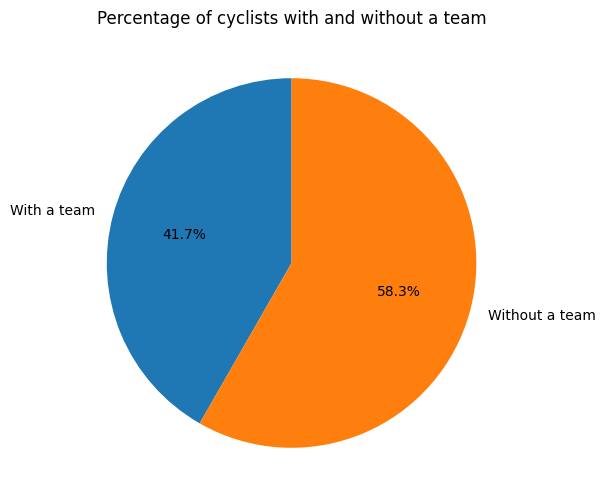

In [281]:
labels = ['With a team', 'Without a team']
sizes = [cyclists_with_team, cyclists_with_null_team]

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)

plt.title('Percentage of cyclists with and without a team')
plt.show()

We then look for how many cyclists appear both with and without a team among the various racing placings

In [282]:
# groupby cyclist and apply a function to the cyclist_team column, to identify cyclists who have both null and not null values in cyclist team
cyclists_with_inconsistency = placements.groupby('cyclist')['cyclist_team'].apply(lambda x: x.notnull().any() and x.isnull().any())
cyclists_with_inconsistency_number = cyclists_with_inconsistency.sum()
print(cyclists_with_inconsistency_number)

672


We have obtained 672, which is exactly the difference between (2823 + 3944) - 6095

#### Percentage of placements without a team for each cyclist who has both race with team and without

In [283]:
cyclists_with_inconsistency_list = cyclists_with_inconsistency[cyclists_with_inconsistency].index.tolist()

data = []

for cyclist in cyclists_with_inconsistency_list:
    total_placements = placements[placements['cyclist'] == cyclist].shape[0]  
    no_team_placements = placements[(placements['cyclist'] == cyclist) & (placements['cyclist_team'].isnull())].shape[0]  
    team_placements = total_placements - no_team_placements  

    if team_placements > 0:
        # Calcola la percentuale di gare senza team
        percentage_no_team = (no_team_placements / total_placements) * 100
    else:
        percentage_no_team = 100  # Se tutte le gare sono senza team

    # Aggiungi i dati al DataFrame
    data.append({
        'Cyclist': cyclist,
        'Total placements': total_placements,
        'placements Without Team': no_team_placements,
        'placements With Team': team_placements,
        'Percentage Without Team': f"{percentage_no_team:.2f}%"
    })
df_inconsistencies = pd.DataFrame(data)

display(df_inconsistencies)

,Cyclist,Total placements,placements Without Team,placements With Team,Percentage Without Team
0,adam-de-vos,5,1,4,20.00%
1,adam-hansen,699,127,572,18.17%
2,adam-yates,444,43,401,9.68%
3,adriano-malori,206,38,168,18.45%
4,adrien-petit,237,22,215,9.28%
...,...,...,...,...,...
667,yann-huguet,84,28,56,33.33%
668,yannis-voisard,39,14,25,35.90%
669,yoann-offredo,169,18,151,10.65%
670,yukihiro-doi,58,36,22,62.07%


#### Percentage distribution
The percentage shown in the distribution represents the ratio of races in which a cyclist did not have a team, compared to the total number of races the cyclist participated in. This provides insight into how often a cyclist was without a team across all their race entries.

<Figure size 1000x600 with 0 Axes>

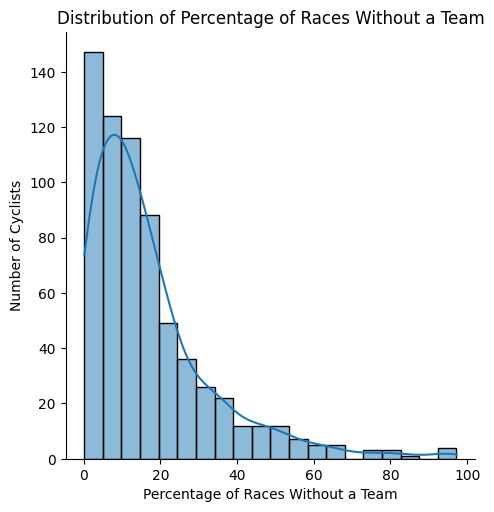

In [284]:
df_inconsistencies['Percentage Without Team'] = df_inconsistencies['Percentage Without Team'].replace('%', '', regex=True).astype(float)

plt.figure(figsize=(10, 6))
sbn.displot(df_inconsistencies['Percentage Without Team'], kde=True, bins=20)

plt.title('Distribution of Percentage of Races Without a Team')
plt.xlabel('Percentage of Races Without a Team')
plt.ylabel('Number of Cyclists')
plt.show()

# New features


# Correlation analysis

In [285]:
numeric_placements_data = placements.select_dtypes(include="number")
numeric_placements_data.corr()

,position,cyclist_age,delta,null_count,year,year_group,max_previous
position,1.000000,0.011984,0.236165,0.047225,0.142047,0.141517,0.234423
cyclist_age,0.011984,1.000000,0.000504,-0.100785,0.152419,0.152466,0.000445
delta,0.236165,0.000504,1.000000,-0.012060,0.074633,0.074886,0.993072
null_count,0.047225,-0.100785,-0.012060,1.000000,-0.425828,-0.425536,-0.014042
year,0.142047,0.152419,0.074633,-0.425828,1.000000,0.999052,0.074583
year_group,0.141517,0.152466,0.074886,-0.425536,0.999052,1.000000,0.074840
max_previous,0.234423,0.000445,0.993072,-0.014042,0.074583,0.074840,1.000000


# Imputation

In [286]:
def imputationComparison(original_df, imputed_df, column):
    #Two plots in the same row
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sbn.histplot(original_df, x=column, ax=axes[0], kde=True)
    axes[0].set_title(f'Histogram of "{column}" pre-imputation')
    axes[0].set_xlabel(column)
    axes[0].set_ylabel('Frequency')

    sbn.histplot(imputed_df, x=column, ax=axes[1], kde=True)
    axes[1].set_title(f'Histogram of "{column}" after-imputation')
    axes[1].set_xlabel(column)
    axes[1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()
    plt.close()

## Cyclist_age

In [287]:
cyclists.columns

Index(['_url', 'name', 'birth_year', 'weight', 'height', 'nationality'], dtype='object')

In [288]:
imputed_cyclists.columns

Index(['name', 'BMI', 'median position', 'AVG position', '# cyclist races',
       'nationality', 'continent', 'geo area', 'birth_year',
       'AVG weighted position', 'AVG position Autumn', 'AVG position Spring',
       'AVG position Summer', 'AVG position Winter', 'AVG position Q1',
       'AVG position Q2', 'AVG position Q3', 'AVG position Q4',
       'std_dev position'],
      dtype='object')

In [289]:
#Cyclists without a 'cyclist_age' reference in 'placements'
no_age_in_placements=placements[placements['cyclist_age'].isna()]['cyclist'].drop_duplicates().tolist()
sorted(no_age_in_placements)

['alexandr-osipov',
 'antonio-zanini',
 'batik-odriozola',
 'carlos-garcia',
 'filippo-simonetti',
 'javier-luquin',
 'nevens-guy',
 'nicolai-kosyakov',
 'oscar-pumar',
 'scott-davies',
 'sergei-jermachenko',
 'thierry-lauder',
 'vladimir-malakov']

In [290]:
#Cyclists without a 'birth_year' reference in 'cyclist' after the initial imputation
no_by_in_cyclists=imputed_cyclists[imputed_cyclists['birth_year'].isna()]['name'].drop_duplicates().tolist()
sorted(no_by_in_cyclists)

['alexandr-osipov',
 'batik-odriozola',
 'carlos-garcia',
 'filippo-simonetti',
 'javier-luquin',
 'nevens-guy',
 'nicolai-kosyakov',
 'oscar-pumar',
 'sergei-jermachenko',
 'thierry-lauder']

We can see that after the '_birth year_' imputation on the 'cyclists' dataset, we can determine the correct value for 3 cyclists with a NaN '_cyclist age_'; these cyclists are 'antonio-zanini', 'scott-davies', 'vladimir-malakov'.

The other cyclists with a NaN '_cyclist age_' in the 'placements' dataset also have a NaN '_birth year_' in the 'cyclists' dataset. So we can decide to impute one of the two features and automatically determine the values for the other.

### Birth year known
We use the information from the imputed cyclist dataset. Basically, we calculate the difference between the year in which the race took place and the year of birth of the cyclist

In [291]:
print(placements[placements['cyclist'] == 'antonio-zanini']['date'].dt.year.value_counts())
#All the races the same year
rows_to_fill = placements[placements['cyclist']== 'antonio-zanini']

date
1990    2
Name: count, dtype: int64


In [292]:
cyclist_age=rows_to_fill['date'].iloc[0].year-imputed_cyclists[imputed_cyclists['name']=='antonio-zanini']['birth_year'].iloc[0]
#All the races in the same year
print(f'In all the races in which he has participated, antonio zanini was {cyclist_age}')
rows_to_fill.loc[:, 'cyclist_age'] = rows_to_fill['cyclist_age'].fillna(cyclist_age)
placements.update(rows_to_fill) 

In all the races in which he has participated, antonio zanini was 25.0


/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_86905/113183178.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1970 1970 1970 ... 2022 2022 2022]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  placements.update(rows_to_fill)
/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_86905/113183178.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1970 1970 1970 ... 2022 2022 2022]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  placements.update(rows_to_fill)


In [293]:
placements[placements['cyclist']=='antonio-zanini'][['cyclist', 'cyclist_age', 'date']] #post imputation

,cyclist,cyclist_age,date
210187,antonio-zanini,25,1990-04-08
214103,antonio-zanini,25,1990-04-01


In [294]:
print(placements[placements['cyclist'] == 'vladimir-malakov']['date'].dt.year.value_counts())
#All the races the same year
rows_to_fill = placements[placements['cyclist']== 'vladimir-malakov']

date
1985    14
Name: count, dtype: int64


In [295]:
cyclist_age=rows_to_fill['date'].iloc[0].year-imputed_cyclists[imputed_cyclists['name']=='vladimir-malakov']['birth_year'].iloc[0]
#All the placements in the same year
print(f'In all the races in which he has participated, vladimir-malakov was {cyclist_age}')
rows_to_fill.loc[:, 'cyclist_age'] = rows_to_fill['cyclist_age'].fillna(cyclist_age)
placements.update(rows_to_fill) 

In all the races in which he has participated, vladimir-malakov was 27.0


In [296]:
placements[placements['cyclist']=='vladimir-malakov'][['cyclist', 'cyclist_age', 'date']]

,cyclist,cyclist_age,date
487129,vladimir-malakov,27,1985-04-23
487215,vladimir-malakov,27,1985-05-03
487383,vladimir-malakov,27,1985-05-04
487476,vladimir-malakov,27,1985-05-05
487652,vladimir-malakov,27,1985-05-07
487687,vladimir-malakov,27,1985-05-08
487745,vladimir-malakov,27,1985-05-09
487882,vladimir-malakov,27,1985-05-10
487977,vladimir-malakov,27,1985-05-11
488030,vladimir-malakov,27,1985-05-12


In [297]:
print(placements[placements['cyclist'] == 'scott-davies']['date'].dt.year.value_counts())
#Races in different years!

date
2019    29
2020    18
2018     5
Name: count, dtype: int64


In [298]:
#Races in 2018
year=2018
for year in range(2018, 2021):
    # Select the rows related to races of scott davies in 'year'
    rows_to_fill = placements[(placements['cyclist']== 'scott-davies')&(placements['date'].dt.year==year)]
    cyclist_age=rows_to_fill['date'].iloc[0].year-imputed_cyclists[imputed_cyclists['name']=='scott-davies']['birth_year'].iloc[0]
    print(f'In all the races of {year} in which he has participated, scott-davies was {cyclist_age}')
    rows_to_fill.loc[:, 'cyclist_age'] = rows_to_fill['cyclist_age'].fillna(cyclist_age)
    placements.update(rows_to_fill) 

In all the races of 2018 in which he has participated, scott-davies was 23.0
In all the races of 2019 in which he has participated, scott-davies was 24.0
In all the races of 2020 in which he has participated, scott-davies was 25.0


In [299]:
placements[placements['cyclist']=='scott-davies'][['cyclist', 'cyclist_age', 'date']]

,cyclist,cyclist_age,date
3908,scott-davies,23,2018-04-15
116109,scott-davies,24,2019-05-11
116389,scott-davies,24,2019-05-21
116561,scott-davies,24,2019-05-22
116678,scott-davies,24,2019-05-23
116822,scott-davies,24,2019-05-24
116976,scott-davies,24,2019-05-25
117109,scott-davies,24,2019-05-26
117245,scott-davies,24,2019-05-28
117415,scott-davies,24,2019-05-29


### Birth year unknown
For cyclists _X_ with an unknown birth year, we decide to make the imputation using as a reference the median age of cyclists taking part in races with _X_.

In [300]:
imputed_cyclists[imputed_cyclists['name'].isin(no_by_in_cyclists)][['name', '# cyclist races']].sort_values('# cyclist races', ascending=False)

,name,# cyclist races
4091,sergei-jermachenko,14
4086,alexandr-osipov,13
4098,nicolai-kosyakov,11
4027,filippo-simonetti,1
4815,nevens-guy,1
5292,thierry-lauder,1
5672,carlos-garcia,1
5679,javier-luquin,1
5831,oscar-pumar,1
6059,batik-odriozola,1


Many of these cyclists have participated only in one race event. The idea is to replace the missing age of the cyclists with the median age, taking into account the races in which they have participated. 

In [301]:
placements[placements['cyclist'].isin(no_by_in_cyclists)][['cyclist', 'year']].value_counts()

cyclist             year
sergei-jermachenko  1985    14
alexandr-osipov     1985    12
nicolai-kosyakov    1985    11
alexandr-osipov     1986     1
batik-odriozola     1997     1
carlos-garcia       2001     1
filippo-simonetti   1997     1
javier-luquin       1992     1
nevens-guy          1993     1
oscar-pumar         1995     1
thierry-lauder      2000     1
Name: count, dtype: int64

In [302]:
print(placements[placements['cyclist'] == 'alexandr-osipov']['year'].value_counts())

year
1985    12
1986     1
Name: count, dtype: int64


Only Alexandr Osipov has taken part in the race in different years.

In [303]:
#Iterate over all the cyclists without birth year
for cyclist in no_by_in_cyclists:
    #Extract the races in which he has participated (the _url)
    races_in_which_he_has_participated=placements[placements['cyclist']==cyclist]['_url']

    #Determine the median age of the participants of the races in which the cyclist took part in
    median_age=placements[placements['_url'].isin(races_in_which_he_has_participated)]['cyclist_age'].median()
    print(f"The median age of the race events in which {cyclist} took part was {median_age}")
    
    #With the exception of 'Alexandr-Osipov', all the cyclists have only taken part in races in the same year.
    if cyclist!= 'alexandr-osipov':
        #Extract the rows to fill
        rows_to_fill = placements[(placements['cyclist']== cyclist)]
        #Fill NaNs
        rows_to_fill.loc[:, 'cyclist_age'] = rows_to_fill['cyclist_age'].fillna(median_age)
        placements.update(rows_to_fill) 
    else:
        #He participated in 12 race events in 1985 and only 1 in 1986
        rows_to_fill = placements[(placements['cyclist']== cyclist)&(placements['date'].dt.year==1985)]
        rows_to_fill.loc[:, 'cyclist_age'] = rows_to_fill['cyclist_age'].fillna(median_age)
        placements.update(rows_to_fill) 
        rows_to_fill = placements[(placements['cyclist']== cyclist)&(placements['date'].dt.year==1986)]
        rows_to_fill.loc[:, 'cyclist_age'] = rows_to_fill['cyclist_age'].fillna(median_age+1)
        placements.update(rows_to_fill) 

The median age of the race events in which filippo-simonetti took part was 28.0
The median age of the race events in which alexandr-osipov took part was 26.0
The median age of the race events in which sergei-jermachenko took part was 26.0
The median age of the race events in which nicolai-kosyakov took part was 26.0
The median age of the race events in which nevens-guy took part was 28.0
The median age of the race events in which thierry-lauder took part was 28.0
The median age of the race events in which carlos-garcia took part was 28.0
The median age of the race events in which javier-luquin took part was 27.0
The median age of the race events in which oscar-pumar took part was 28.0
The median age of the race events in which batik-odriozola took part was 27.0


In [304]:
print(f"After the imputation there are {placements[placements['cyclist_age'].isna()].shape[0]} rows with still a NaN value.")

After the imputation there are 0 rows with still a NaN value.


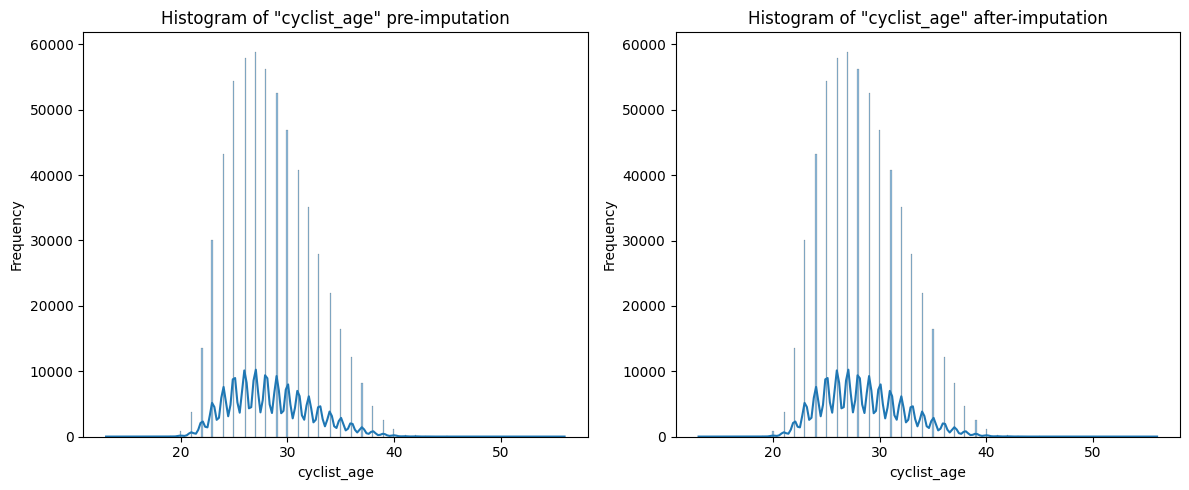

In [305]:
imputationComparison(placements_pre_imputation, placements, 'cyclist_age')

/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_86905/1300890385.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


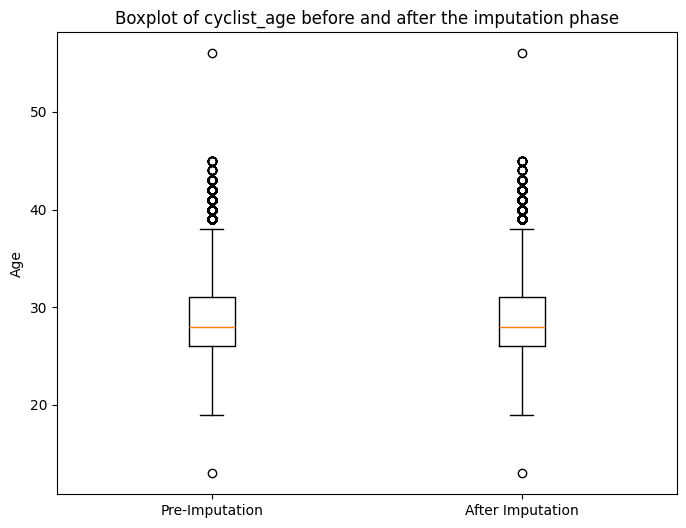

In [306]:
plt.figure(figsize=(8, 6))

#Unique boxplot with multiple datasets representing the initial situation and the imputation strategies
plt.boxplot(
    [placements_pre_imputation['cyclist_age'].dropna(), placements['cyclist_age']],
    labels=['Pre-Imputation', 'After Imputation']
)
plt.title("Boxplot of cyclist_age before and after the imputation phase")
plt.ylabel("Age")
plt.show()
plt.close()

As shown, we have not altered the distribution of the cyclists ages.

In [307]:
placements.to_csv('../dataset/preprocessedPlacements.csv', index=False)